In [3]:
!git clone https://github.com/hamse-ai/Multimodal_Data_Preprocessing.git

Cloning into 'Multimodal_Data_Preprocessing'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 91 (delta 25), reused 30 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 2.02 MiB | 8.30 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [4]:
import os

PROJECT = "/content/Multimodal_Data_Preprocessing"
os.chdir(PROJECT)
print(os.getcwd())

/content/Multimodal_Data_Preprocessing


In [5]:
!pip install librosa soundfile -q

In [6]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

In [7]:
AUDIO_DIR = "data/audio"
AUGMENT_DIR = "data/augmented"
os.makedirs(AUGMENT_DIR, exist_ok=True)

In [8]:
audio_files = [
    f for f in os.listdir(AUDIO_DIR)
    if f.endswith(".wav")
]

print(audio_files)

['Celine_Yes, approve.wav', 'Celine_Confirm_transaction.wav', 'David_Yes, approve..mp3.wav', 'David_confirm transaction.mp3.wav', 'confirm_hamse.mp3.wav', 'yes_hamse.mp3.wav']


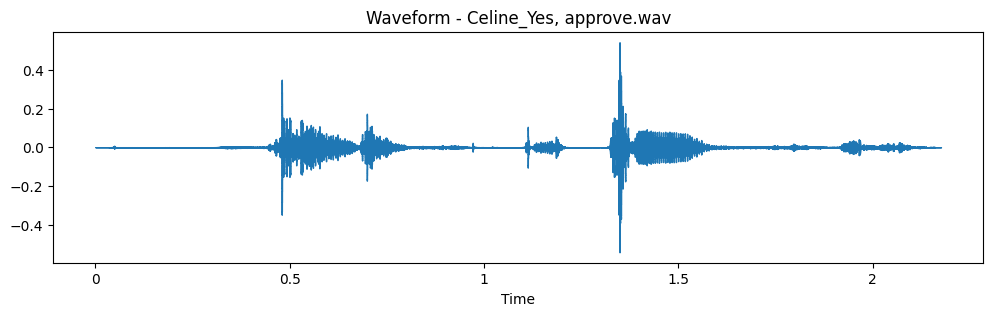

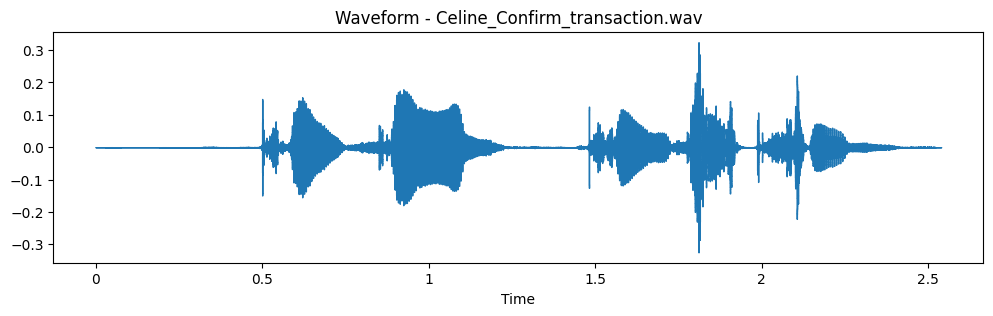

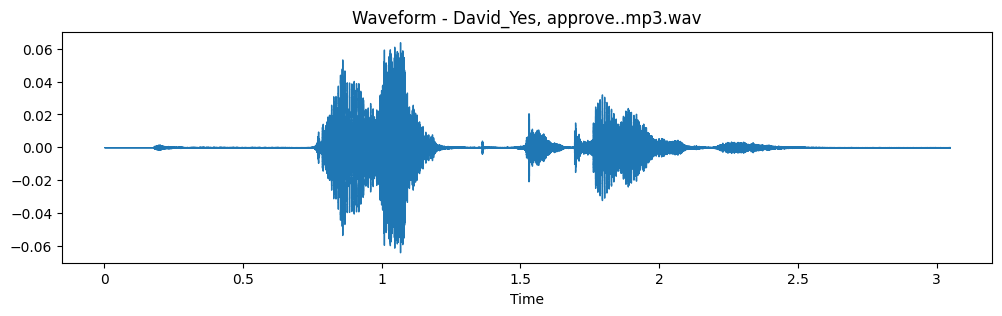

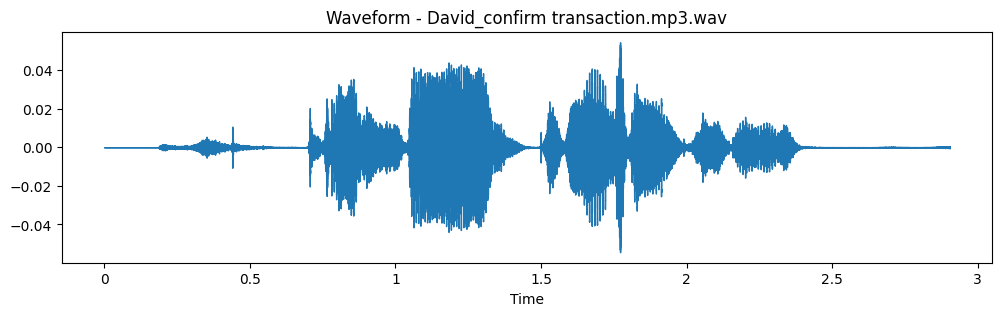

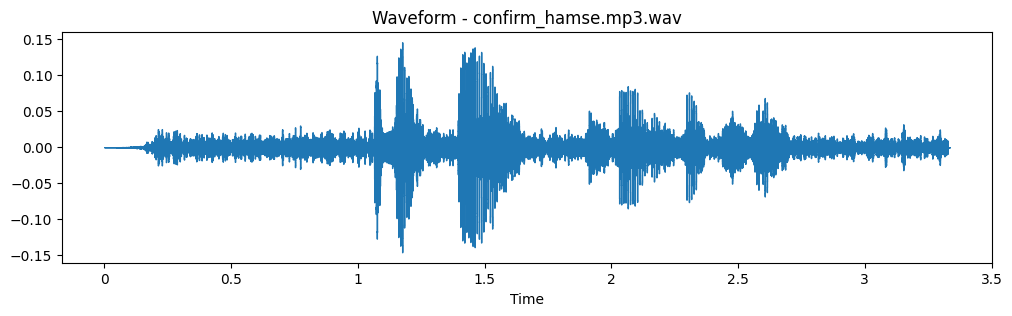

In [10]:
import os

REPORT_DIR = "data/reports"
os.makedirs(REPORT_DIR, exist_ok=True)

for file in audio_files:

    y, sr = librosa.load(os.path.join(AUDIO_DIR, file), sr=None)
    plt.figure(figsize=(12,3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform - {file}")
    plt.savefig(os.path.join(REPORT_DIR, f"waveform_{file}.png"))
plt.close()

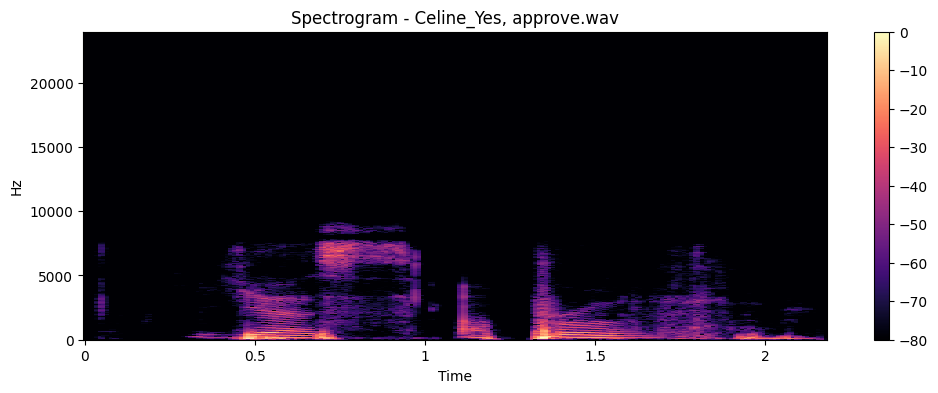

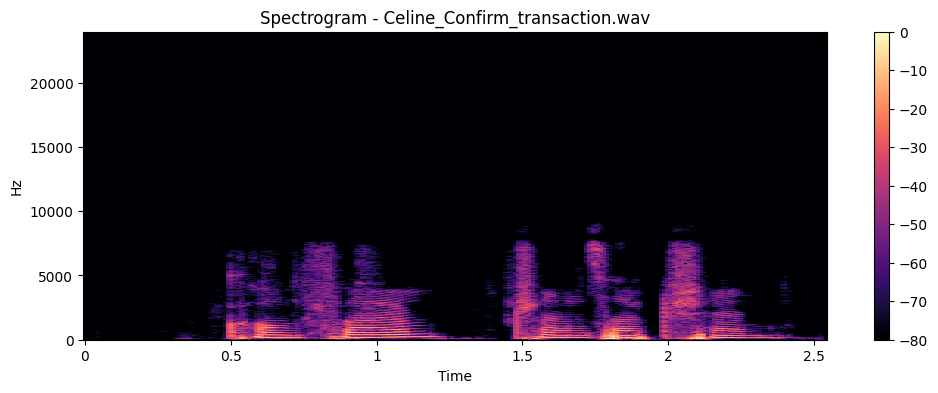

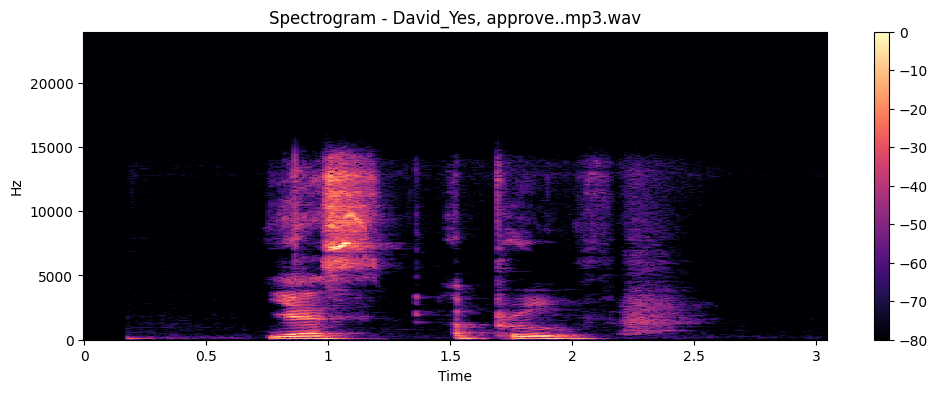

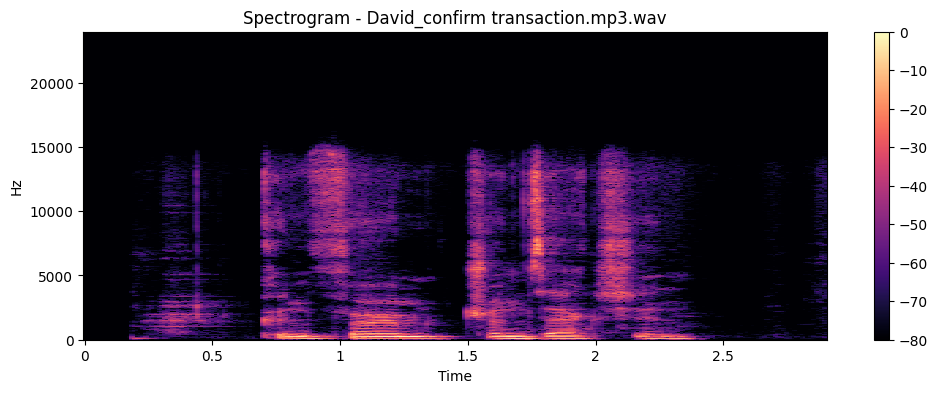

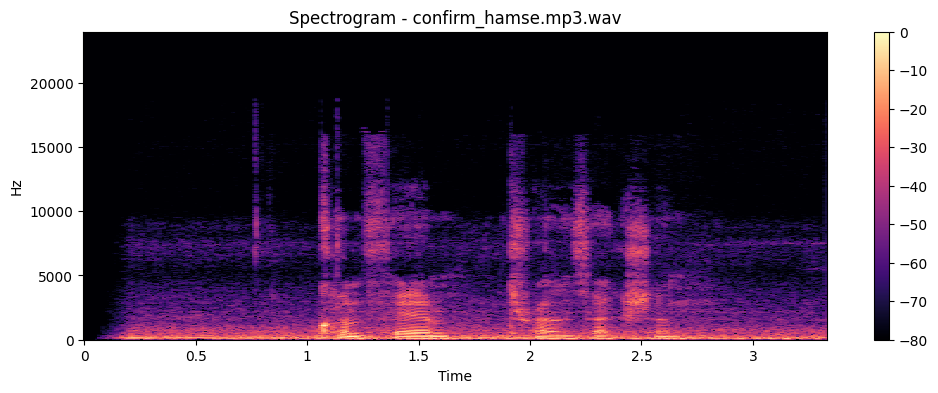

In [11]:
for file in audio_files:

    y, sr = librosa.load(os.path.join(AUDIO_DIR, file), sr=None)
    D = librosa.amplitude_to_db(
        np.abs(librosa.stft(y)),
        ref=np.max
    )

    plt.figure(figsize=(12,4))
    librosa.display.specshow(
        D,
        sr=sr,
        x_axis="time",
        y_axis="hz"
    )

    plt.colorbar()
    plt.title(f"Spectrogram - {file}")
    plt.savefig(os.path.join(REPORT_DIR, f"spectrogram_{file}.png"))
plt.close()

In [12]:
def pitch_shift(y, sr):
    return librosa.effects.pitch_shift(
        y=y,
        sr=sr,
        n_steps=2
    )

def stretch(y):
    return librosa.effects.time_stretch(
        y=y,
        rate=1.2
    )

def add_noise(y):
    noise = np.random.randn(len(y))
    return y + 0.005 * noise

In [13]:
for file in audio_files:

    y, sr = librosa.load(os.path.join(AUDIO_DIR,file), sr=None)
    sf.write(
        os.path.join(AUGMENT_DIR,"pitch_"+file),
        pitch_shift(y,sr),
        sr
    )

    sf.write(
        os.path.join(AUGMENT_DIR,"stretch_"+file),
        stretch(y),
        sr
    )

    sf.write(
        os.path.join(AUGMENT_DIR,"noise_"+file),
        add_noise(y),
        sr
    )

print("Done!")

Done!


In [14]:
def extract_features(path):

    y, sr = librosa.load(path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)

    return {

        "file": os.path.basename(path),
        "mfcc_mean": np.mean(mfcc),
        "mfcc_std": np.std(mfcc),
        "rolloff_mean": np.mean(rolloff),
        "rolloff_std": np.std(rolloff),
        "energy_mean": np.mean(rms),
        "energy_std": np.std(rms)

    }

In [15]:
features = []

for file in audio_files:

    features.append(
        extract_features(
            os.path.join(AUDIO_DIR,file)
        )
    )

for file in os.listdir(AUGMENT_DIR):
    if file.endswith(".wav"):
        features.append(
            extract_features(
                os.path.join(AUGMENT_DIR,file)
            )
        )

df = pd.DataFrame(features)
df

,file,mfcc_mean,mfcc_std,rolloff_mean,rolloff_std,energy_mean,energy_std
0,"Celine_Yes, approve.wav",-27.543978,153.238495,4313.871951,4198.890406,0.014223,0.024003
1,Celine_Confirm_transaction.wav,-25.631062,147.475510,3503.563023,4019.330526,0.019360,0.022821
2,"David_Yes, approve..mp3.wav",-46.620495,201.300797,10596.126530,5535.013536,0.002932,0.005318
3,David_confirm transaction.mp3.wav,-38.932278,179.267380,7773.437500,5688.420354,0.005383,0.006574
4,confirm_hamse.mp3.wav,-17.056015,143.845734,3026.732228,2645.518484,0.012138,0.008847
5,yes_hamse.mp3.wav,-17.211969,138.958221,4062.102273,3161.509221,0.016112,0.016387
6,"stretch_Celine_Yes, approve.wav",-28.966177,157.055176,4792.900219,4975.454616,0.009846,0.017130
7,"pitch_Celine_Yes, approve.wav",-30.528723,166.038559,5130.182927,4956.724516,0.008741,0.012861
8,noise_yes_hamse.mp3.wav,-13.085564,86.870720,18224.232955,2982.953223,0.017477,0.015721
9,stretch_David_confirm transaction.mp3.wav,-41.209564,192.645889,8543.949615,5913.550011,0.002990,0.003114


In [16]:
df = pd.DataFrame(features)

csv_path = os.path.join(PROJECT, "data/audio_features.csv")
df.to_csv(csv_path, index=False)
print(df)
print("\nSaved to:")
print(csv_path)

                                         file  mfcc_mean    mfcc_std  \
0                     Celine_Yes, approve.wav -27.543978  153.238495   
1              Celine_Confirm_transaction.wav -25.631062  147.475510   
2                 David_Yes, approve..mp3.wav -46.620495  201.300797   
3           David_confirm transaction.mp3.wav -38.932278  179.267380   
4                       confirm_hamse.mp3.wav -17.056015  143.845734   
5                           yes_hamse.mp3.wav -17.211969  138.958221   
6             stretch_Celine_Yes, approve.wav -28.966177  157.055176   
7               pitch_Celine_Yes, approve.wav -30.528723  166.038559   
8                     noise_yes_hamse.mp3.wav -13.085564   86.870720   
9   stretch_David_confirm transaction.mp3.wav -41.209564  192.645889   
10              stretch_confirm_hamse.mp3.wav -19.960581  151.018982   
11       pitch_Celine_Confirm_transaction.wav -29.275734  160.840485   
12     stretch_Celine_Confirm_transaction.wav -27.665859  157.04

In [17]:
from google.colab import files
files.download("data/audio_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>